In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

from lmpy import data, lm, lme

## Examples from *lme4: Mixed-effects Modeling with R* (Bates, 2010)

### 1.3.1

In [2]:
Dyestuff = data('Dyestuff', 'lme4')
fm01 = lme('Yield ~ 1 + (1|Batch)', Dyestuff)              # REML default
fm01.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1|Batch)

REML criterion at convergence: 319.6543

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4117 -0.7634 0.1418 0.7792 1.8296

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1764     42.00
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    1527.5     19.3835   78.804


Same fit by ML

In [3]:
fm01ML = lme('Yield ~ 1 + (1|Batch)', Dyestuff, REML=False)
fm01ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1|Batch)

     AIC      BIC    logLik -2*log(L) df.resid
333.3271 337.5307 -163.6635  327.3271       27

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4315 -0.7972 0.1480 0.7721 1.8037

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1388     37.26
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    1527.5     17.6944  86.3266


In [4]:
Dyestuff2 = data('Dyestuff2', 'lme4')
fm02 = lme('Yield ~ 1 + (1|Batch)', Dyestuff2)
fm02.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1|Batch)

REML criterion at convergence: 161.8283

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7648 -0.7806 -0.0809 0.6689 2.0907

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.81    3.716
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6784   8.3516


In [5]:
fm02ML = lme('Yield ~ 1 + (1|Batch)', Dyestuff2, REML=False)
fm02ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1|Batch)

     AIC      BIC   logLik -2*log(L) df.resid
168.8730 173.0766 -81.4365  162.8730       27

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7950 -0.7940 -0.0823 0.6803 2.1264

Random effects:
 Groups   Name        Variance  Std.Dev.
 Batch    (Intercept) 1.176e-14 1.085e-07
 Residual             13.35     3.653
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656       0.667   8.4943


In [10]:
fm02a = lm('Yield ~ 1', Dyestuff2)
fm02a.summary()

Formula: Yield ~ 1

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t values  Pr(>|t|)     
(Intercept)     5.666       0.678     4.278      7.053     8.352       0.0  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 1, Residual SE = 3.716 on 29 DF
R-Squared = -0.0000, adjusted R-Squared = -0.0000
Log Likelihood = -81.4365, AIC = 166.8730, BIC = 169.6754


### 1.4.2 Design Matrices

The book walks through the matrices the fit builds. For `fm01ML` (`Yield ~ 1 + (1|Batch)`, 30 obs over 6 batches):

- `X` — fixed-effects design, 30 × 1 (an intercept column),
- `Z` — random-effects design, 30 × 6 (indicators for `Batch`),
- `θ` — variance-component parameter (here a single scalar),
- `Λ(θ)` — relative covariance factor, 6 × 6; `Σ = σ² Λ Λᵀ`.

`X`, `Z`, and `θ` sit directly on the fitted object as `fm01ML.X`, `fm01ML.Z`, `fm01ML.theta`. `Λ` is built by plugging `θ` into the integer template `fm01ML._re.Lambdat`. The book images `Λ` (Fig. 1.3) and `Zᵀ` (Fig. 1.4) — non-zero cells filled, zero blank.

Z (30, 6)   Λ (6, 6)   θ = [0.75257128]


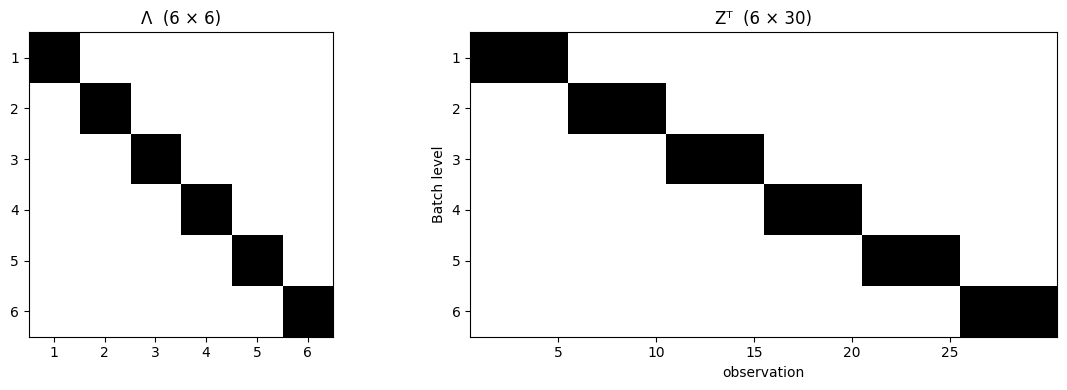

In [29]:
X     = fm01ML.X.to_numpy()
Z     = fm01ML.Z
theta = fm01ML.theta
# Λᵀ is reconstructed by plugging θ into an integer template:
tpl   = fm01ML._re.Lambdat
Lt    = np.zeros(tpl.shape)
Lt[tpl > 0] = theta[tpl[tpl > 0] - 1]
Lam   = Lt.T

print(f'Z {Z.shape}   Λ {Lam.shape}   θ = {theta}')

fig, ax = plt.subplot_mosaic(mosaic="AB", figsize=(12, 4))

ax["A"].imshow(Lam != 0, cmap='Greys', vmin=0, vmax=1)
ax["A"].set_title('Λ  (6 × 6)')
ax["A"].set_xticks(range(6))
ax["A"].set_yticks(range(6))
ax["A"].set_xticklabels(range(1, 7))
ax["A"].set_yticklabels(range(1, 7))

ax["B"].imshow(Z.T != 0, cmap='Greys', vmin=0, vmax=1, aspect='auto')
ax["B"].set_title('Zᵀ  (6 × 30)')
ax["B"].set_yticks(range(6))
ax["B"].set_yticklabels(range(1, 7))
ax["B"].set_xticks([4, 9, 14, 19, 24])
ax["B"].set_xticklabels([5, 10, 15, 20, 25])
ax["B"].set_xlabel('observation')
ax["B"].set_ylabel('Batch level')

plt.tight_layout()
plt.show()

In [30]:
Lt

array([[0.75257128, 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.75257128, 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.75257128, 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.75257128, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.75257128,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.75257128]])

### Ch 2 § 2.1 — `Penicillin`: crossed random factors

In [6]:
Penicillin = data('Penicillin', 'lme4')
fm03 = lme('diameter ~ 1 + (1|plate) + (1|sample)', Penicillin)
fm03.summary()

Linear mixed model fit by REML
Formula: diameter ~ 1 + (1|plate) + (1|sample)

REML criterion at convergence: 330.8606

Random effects:
 Groups   Name        Variance Std.Dev.
 plate    (Intercept) 0.7168   0.8466
 sample   (Intercept) 3.7316   1.9317
 Residual             0.3024   0.5499
Number of obs: 144, groups:  plate, 24; sample, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   22.9722      0.8086  28.4086


### Ch 2 § 2.2 — `Pastes`: nested random factors and an LRT for σ_batch = 0

`fm04` includes both `(1|sample)` and `(1|batch)`. The reduced model
`fm04a` drops `(1|batch)`. Bates uses `anova(fm04a, fm04)` to test
whether σ_batch is non-zero (book § 2.2.4).

In [8]:
Pastes = data('Pastes', 'lme4')
fm04  = lme('strength ~ 1 + (1|sample) + (1|batch)', Pastes, REML=False)
fm04a = lme('strength ~ 1 + (1|sample)',             Pastes, REML=False)
fm04.summary()
print("\n")
fm04a.summary()

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1|sample) + (1|batch)

     AIC      BIC    logLik -2*log(L) df.resid
255.9945 264.3718 -123.9972  247.9945       56

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 8.4319   2.9038
 batch    (Intercept) 1.1983   1.0947
 Residual             0.6782   0.8235
Number of obs: 60, groups:  sample, 30; batch, 10

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533       0.642  93.5375


Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1|sample)

     AIC      BIC    logLik -2*log(L) df.resid
254.4017 260.6847 -124.2008  248.4017       57

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 9.633    3.1038
 Residual             0.678    0.8234
Number of obs: 60, groups:  sample, 30

Fixed effects:
             Estimate  Std. Error   t value
(Intercept)   60.0533      0.5765  104.1599


In [9]:
chisq = fm04a.deviance - fm04.deviance
df    = fm04.npar - fm04a.npar
p     = chi2.sf(chisq, df)
print(f'LRT fm04a vs fm04:  chisq={chisq:.4f}  df={df}  p={p:.4f}')

LRT fm04a vs fm04:  chisq=0.4072  df=1  p=0.5234


### Ch 3 § 3.2 — `sleepstudy`: random slopes

`fm07` is the **uncorrelated** version: `(1|Subject) +
(0+Days|Subject)`. Because the same group `Subject` appears in two
bars, the second one shows up under the disambiguated key
`Subject.1`.

In [10]:
sleepstudy = data('sleepstudy', 'lme4')
fm07 = lme(
    'Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)',
    sleepstudy, REML=False,
)
fm07.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1762.0033 1777.9680 -876.0016 1752.0033      175

Random effects:
 Groups    Name        Variance Std.Dev.
 Subject   (Intercept) 584.25   24.171
 Subject.1 Days        33.63    5.799
 Residual              653.12   25.556
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  251.4051      6.7077  37.4802
Days          10.4673      1.5193   6.8895


`fm06` is the **correlated** version: `(1+Days|Subject)` — a single
vector bar of size 2, fitting an intercept SD, a slope SD, and one
correlation parameter.

In [11]:
fm06 = lme('Reaction ~ 1 + Days + (1+Days|Subject)', sleepstudy, REML=False)
fm06.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1+Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1763.9393 1783.0971 -875.9697 1751.9393      174

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 Subject  (Intercept) 565.51   23.780
          Days        32.68    5.717    0.08
 Residual             654.94   25.592
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  251.4051      6.6322  37.9065
Days          10.4673      1.5022   6.9678


LRT for the correlation: `fm06` adds 1 parameter (the off-diagonal of
the Cholesky factor) over `fm07`. Book result: χ²=0.0639, p=0.8004.

In [12]:
chisq = fm07.deviance - fm06.deviance
df    = fm06.npar - fm07.npar
p     = chi2.sf(chisq, df)
print(f'LRT fm07 vs fm06:  chisq={chisq:.4f}  df={df}  p={p:.4f}')

LRT fm07 vs fm06:  chisq=0.0639  df=1  p=0.8004


### Ch 4 § 4.1 — `Machines`: fixed factor + nested random factor

In [13]:
Machines = data('Machines', 'nlme')
fm10 = lme(
    'score ~ Machine + (1|Worker) + (1|Machine:Worker)',
    Machines, REML=False,
)
fm10.summary()

Linear mixed model fit by maximum likelihood
Formula: score ~ Machine + (1|Worker) + (1|Machine:Worker)

     AIC      BIC    logLik -2*log(L) df.resid
237.2694 249.2034 -112.6347  225.2694       48

Random effects:
 Groups         Name        Variance Std.Dev.
 Machine:Worker (Intercept) 11.5330  3.3960
 Worker         (Intercept) 19.0478  4.3644
 Residual                   0.9248   0.9617
Number of obs: 54, groups:  Machine:Worker, 18; Worker, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   52.3556      2.2690  23.0747
MachineB       7.9667      1.9867   4.0099
MachineC      13.9167      1.9867   7.0048


### Ch 4 § 4.2 — `ergoStool`: random vs fixed treatment

`fm16` treats both `Subject` and `Type` as random. `fm17` keeps
`Subject` random but treats `Type` (4 levels) as a fixed effect — the
more conventional choice.

In [14]:
ergoStool = data('ergoStool', 'nlme')
fm16 = lme('effort ~ 1 + (1|Subject) + (1|Type)', ergoStool, REML=False)
fm16.summary()

Linear mixed model fit by maximum likelihood
Formula: effort ~ 1 + (1|Subject) + (1|Type)

     AIC      BIC   logLik -2*log(L) df.resid
144.0224 150.3564 -68.0112  136.0224       32

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1.704    1.305
 Type     (Intercept) 2.265    1.505
 Residual             1.213    1.101
Number of obs: 36, groups:  Subject, 9; Type, 4

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)     10.25      0.8883  11.5383


In [15]:
fm17 = lme('effort ~ 1 + Type + (1|Subject)', ergoStool, REML=False)
fm17.summary()

Linear mixed model fit by maximum likelihood
Formula: effort ~ 1 + Type + (1|Subject)

     AIC      BIC   logLik -2*log(L) df.resid
134.1444 143.6456 -61.0722  122.1444       30

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1.578    1.256
 Residual             1.076    1.037
Number of obs: 36, groups:  Subject, 9

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    8.5556      0.5431  15.7541
TypeT2         3.8889      0.4890   7.9524
TypeT3         2.2222      0.4890   4.5442
TypeT4         0.6667      0.4890   1.3633
